In [1]:
from scipy import constants as const
import numpy as np
from matplotlib import pyplot as plt

import oreonspy as op

plt.rcParams['figure.figsize'] = [6, 6]

In [2]:
# Cavity parameters
#-------------------
# from Jae Yong LEE, et. al. "Time Domain Study on Cavity Ring-Down Signals from a Fabry-Pérot Cavity under Pulsed Laser Excitations" Japanese Journal of Applied Physics, 1999

# Figure 1
#r_a = 0.9995  # Amplitude reflectivity (corresponding to 0.999)
#r_b = 0.9995

# Figure 2
r_a = np.sqrt(0.95)
r_b = np.sqrt(0.95)

t_a = np.sqrt(1. - r_a**2)  # Amplitude transmissivity
print("t_a: {0}".format(t_a))
L = 0.3  # m
L = int(L/(1064e-9))*(1064e-9) # Tuned cavity FSR=0
L = int(L/(1064e-9))*(1064e-9)-0.5*(1064e-9)/2 # Tuned cavity FSR=0.35, 0.38 optimal found by hand

lambd = 1064e-9  # m
k = 2*np.pi / lambd  # 1/m
omega_0 = const.c * k  # rad/s

Loss = 1. - np.power(t_a,2) - np.power(r_a,2)
if  Loss < 0.:
    print("Attenti ai valori")
else:
    print("Loss: {0}".format(Loss))

t_a: 0.22360679774997932
Loss: 0.0


In [3]:
class Cavity_recursive:
    c = 299792458.0  # Speed of light in vacuum [m/s]
    

    def E_in(t, fwhm_duration = None, t_peak = None, height = None):
        pass

    def d(v, t):
        pass

    def __init__(self, t_a=0.001, T_a=None, r_a=0.99, R_a=None, r_b=0.999, R_b=None, L=3000.0, debug=None, log_file=None):
        if T_a is not None:
            self.t_a = np.sqrt(T_a)
        else:
            self.t_a = t_a
        
        if R_a is not None:
            self.r_a = np.sqrt(R_a)
        else:
            self.r_a = r_a

        if R_b is not None:
            self.r_b = np.sqrt(R_b)
        else:
            self.r_b = r_b
        
        self.__L__ = L  # [m]
        self.T = L / self.c  # [s] half cavity round-trip time


    def N_eff(self):
        '''
        Effective number of photon round trips in a FabryPerot cavity (Rakhmanov Eq. 1.57)
        '''
        return 1./np.abs(np.log(self.r_a*self.r_b))
    

    def F(self):
        '''
        Coefficient of finesse
        '''
        return 4.*self.r_a*self.r_b / np.power(1.-self.r_a*self.r_b, 2)

    def tau_s(self):
        '''
        Formula equivalent to Eq. 2.17 (Rakhmanov)

        return 2. * T * N_eff(r_a, r_b)
        '''
        return self.F() * self.__L__ / (np.pi * const.c)

    def Finesse(self):
        '''
        Finesse
        '''
        return np.sqrt(self.F()) * np.pi / 2.
    
    def tau(self):
        return 2. * self.T * self.N_eff()
    
    def v_cr(self):
        return lambd / (2. * self.Finesse() * self.tau())  # In [m/s]!
    
    def gain(self):
        return self.t_a / (1. - self.r_a*self.r_b)

    def simulation(self, k, E_in, d, fwhm_duration, t_peak, impulse_height=1.0e-8):
        self.k2j = -2.j*k

        self.N = int(self.N_eff() * 10)

        if self.N < 1:
            self.N = 1

        self.n = np.arange(0, self.N+1, 1)

        self.rarbn = np.power(self.r_a*self.r_b, self.n)

        self.E_in = E_in
        self.d = d
        self.fwhm_duration = fwhm_duration
        self.t_peak = t_peak
        self.impulse_height = impulse_height

    def sim_step(self, t, v, recursion_level=0):
        '''
        Recursive implementation of Eq. 1.50 from "Dynamics of Laser Interferometric Gravitational Wave Detectors" PhD thesis by M. Rakhmanov
        '''

        if recursion_level > self.N:  # TODO: Verify the accuracy!
            raise RecursionError(f"Maximum recursion depth reached at level {recursion_level}")
        
        try:
            E_last = self.sim_step(t - 2.*self.T, v, recursion_level=recursion_level+1)
        except RecursionError:
            #print("Recursion lvl: {0}".format(recursion_level))
            E_last = 0.
            
        res = self.t_a * self.E_in(t, self.fwhm_duration, self.t_peak, self.impulse_height) + self.r_a * self.r_b * np.exp(self.k2j*self.d(v, t, self.__L__)) * E_last
        return res

In [4]:
cav_test = Cavity_recursive(L=L, r_a=r_a, r_b=r_b, t_a=t_a)

In [5]:
print("Coefficient of finesse: {0:.2f}".format(cav_test.F()))

print("Tau_s: {0}".format(cav_test.tau_s()))

print("Finesse: {0}".format(cav_test.Finesse()))

Coefficient of finesse: 1520.00
Tau_s: 4.841640234467306e-07
Finesse: 61.24091501940457


In [6]:
cav_test.v_cr()

0.2226392645234607

In [7]:
cav_test.N_eff()

19.495725746223627

In [8]:
cav_test.T

1.0006882494689044e-09

In [9]:
cav_test.gain()

4.4721359549995725

## Some cases of $d(t)$

* $d(t) = const.$
* $d(t) = A\sin(2\pi f t)$
* $d(t) = arb(t)$ -- arbitrary function of time

In [10]:
def d(v,t,L):
    """
    
    """
    # Constant
    #return 2

    # Linear    
    #c = 1.
    return v*t + L

    # Sinusoidal
    A = 1.e-7
    f = 200.e6  # Hz
    #return A*np.sin(2.*np.pi*f*t)

In [11]:
def E_in_old(t, fwhm_duration = 2.4e-9, t_peak=5*2.4e-9):
    #return 1.
    #fwhm_duration = 2.4e-9
    #fwhm_duration = 3*2.4e-9
    # Gaussian pulse: 2.4ns duration, peak at t=0.1s, max value 1
    sigma = fwhm_duration / (2 * np.sqrt(2 * np.log(2)))  # Convert FWHM to sigma
    #t_peak = 0.005
    #t_peak = 10*2.4e-9
    return np.exp(-((t - t_peak)**2) / (2 * sigma**2))
    #return np.exp(-((t - t_peak)**2) / (2 * sigma**2))*np.exp(1j*(k-omega_0*t))
    #return A*np.sin(2.*np.pi*f*t)

In [12]:
def E_in(t, fwhm_duration = 2.4e-9, t_peak=5*2.4e-9, height=1.):
    #return 1.
    #fwhm_duration = 2.4e-9
    #fwhm_duration = 3*2.4e-9
    # Gaussian pulse: 2.4ns duration, peak at t=0.1s, max value 1
    sigma = fwhm_duration / (np.sqrt(8 * np.log(2)))  # Convert FWHM to sigma
    #t_peak = 0.005
    #t_peak = 10*2.4e-9
    #return height/(sigma * np.sqrt(2 * np.pi)) * np.exp(-((t - t_peak)**2) / (2 * sigma**2))
    return height * np.exp(-((t - t_peak)**2) / (2 * sigma**2))
    #return np.exp(-((t - t_peak)**2) / (2 * sigma**2))*np.exp(1j*(k-omega_0*t))
    #return A*np.sin(2.*np.pi*f*t)

In [13]:
from scipy.optimize import fsolve

# Test E_in function to verify 2.4ns FWHM pulse parameters
fwhm_duration = 2.4e-9  # 2.4 ns
t_peak = 5 * 2.4e-9    # peak at 12 ns
sigma = fwhm_duration / (np.sqrt(8 * np.log(2)))
height = 0.25e-8

# Test 1: Check peak value occurs at t_peak
peak_value = E_in(t_peak, fwhm_duration, t_peak, height)
expected_peak = height / (sigma * np.sqrt(2 * np.pi))
assert np.isclose(peak_value, expected_peak), f"Peak value mismatch: {peak_value} vs {expected_peak}"
print(f"✓ Peak value correct: {peak_value:.6e}")

# Test 2: Check FWHM (full width at half maximum)
half_max = expected_peak / 2
# Find points where E_in equals half max by solving the Gaussian equation
def find_fwhm_point(t_offset):
    return E_in(t_peak + t_offset, fwhm_duration, t_peak, height) - half_max

t_offset_half = fsolve(find_fwhm_point, fwhm_duration/4)[0]
measured_fwhm = 2 * t_offset_half
assert np.isclose(measured_fwhm, fwhm_duration, rtol=0.01), f"FWHM mismatch: {measured_fwhm} vs {fwhm_duration}"
print(f"✓ FWHM correct: {measured_fwhm*1e9:.2f} ns (expected {fwhm_duration*1e9:.2f} ns)")

# Test 3: Check normalization (integral should equal 1)
t_range = np.linspace(t_peak - 5*sigma, t_peak + 5*sigma, 1000)
integral = np.trapz([E_in(t, fwhm_duration, t_peak, height).real for t in t_range], t_range)
assert np.isclose(integral, 1.0, rtol=0.01), f"Normalization error: integral = {integral}"
print(f"✓ Normalization correct: integral = {integral:.6f}")

print("\nAll E_in tests passed!")

AssertionError: Peak value mismatch: 2.5e-09 vs 0.9785804986454701

In [ ]:
def x_a(t):
    return 0.0

## Implementation of Eq. 1.51

In [14]:
cav_test.simulation(k, E_in, d, fwhm_duration = 2.4e-9, t_peak=5*2.4e-9)

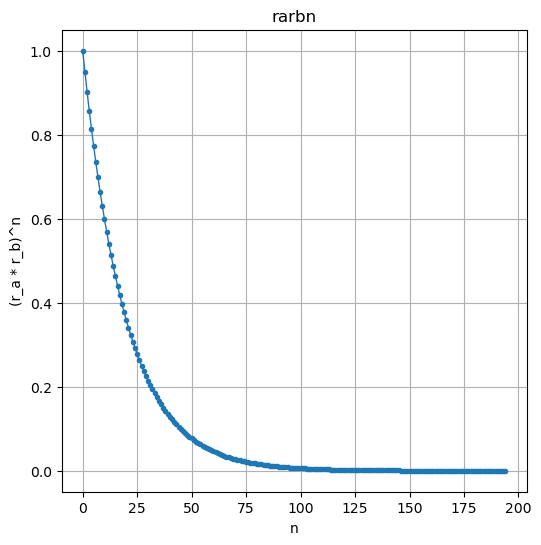

In [15]:
plt.figure()
plt.plot(cav_test.n, cav_test.rarbn, marker='o', ms=3, lw=1)
plt.xlabel("n")
plt.ylabel("(r_a * r_b)^n")
plt.title("rarbn")
plt.grid(True)

In [16]:
v = .01*cav_test.v_cr()  # m/s

cav_test.sim_step(0.01, v)

0j

## Definition of useful arrays

In [17]:
number_of_points = 3000

Airy_power_data = np.zeros(number_of_points, dtype=np.complex_)

ein = np.zeros(number_of_points, dtype=np.complex_)
eref = np.zeros(number_of_points, dtype=np.complex_) #for the values of the reflected field
dyn = np.zeros(number_of_points, dtype=np.complex_) #for the values of the field inside the cavity in case of lenght scan transient
res_dyn = np.zeros(number_of_points, dtype=np.complex_) #for the values of the cavity field obtained numerically
rt_sim_res = np.zeros(number_of_points, dtype=np.complex_)
res = np.zeros(number_of_points, dtype=np.complex_)


## Automation of the comparison between numerical solution and Airy function with selectable velocity.

The function `simulation_check` aims to automatize the process of compare the numerical simulation with the analitycal solution (Airy function), giving the possibility to choose the velocity of $d(t)$ and compute the right time window for visualizing 2 free spectral range. The correct time window is calculated through the function `time_window`.

In [18]:
def time_window(v, number_of_points):
    t_stop = lambd/v
    return np.linspace(0.,t_stop,number_of_points)

In [19]:
import time

plt.rcParams['figure.figsize'] = [10, 7]

def simulation_check(L, detuning=0., tau_factor=1., batch_simulation=False):
    impulse_height = .2e-0*10
    duration = 100e-9  # s
    f_calc = 2.e12  # Hz
    number_of_points = int(duration*f_calc)
    print("Number of points: {0}".format(number_of_points))

    L = int(L/(1064e-9))*(1064e-9)-detuning*(1064e-9)/2 # Tuned cavity FSR=0.35, 0.38 optimal found by hand

    tdata = np.linspace(0, duration, number_of_points)

    ein = np.zeros(len(tdata), dtype=np.complex_)
    rt_sim_res = np.zeros(len(tdata), dtype=np.complex_)
    res = np.zeros(len(tdata), dtype=np.complex_)

    cav_test = Cavity_recursive(L=L, r_a=r_a, r_b=r_b, t_a=t_a)
    tau = cav_test.T
    tau = 2.*L/cav_test.c
    print("Tau: {0}".format(tau))
    cav_test.simulation(k, E_in, d, fwhm_duration = tau*tau_factor, t_peak=5*2.4e-9, impulse_height=impulse_height)
    
    # Batch simulation
    if batch_simulation:
        start_time = time.time()
        
        for idx, t in enumerate(tdata):
            ein[idx] = E_in(t, fwhm_duration = tau*tau_factor, t_peak=5*2.4e-9, height=impulse_height)
            res[idx] = cav_test.sim_step(t, 0.)
        
        end_time = time.time()
        elapsed_time = end_time - start_time
        print(f"Batch simulation took {elapsed_time:.4f} seconds")

    # RT simulation
    cavity = op.Cavity(t_a=t_a , r_a=r_a , r_b=r_b , L=L)
    cavity.simulation(k, 1/(tdata[1]-tdata[0]), E_in_init=0.)
    ''' # =====
    Symulator startuje z polem wewnątrz wnęki całkowicie naładowanym. Błąd! Powinien startować z polem naładowanym pomnożonym przez E_in_init.
    Sprawdzić czy o tym już pomyślałem.
    # ===== '''
    cavity.print_sim_params()

    start_time = time.time()

    for idx, t in enumerate(tdata):
        #rt_sim_res[idx],_ = cavity.sim_step(1., 0, lambd/number_of_points)  # Moving mirror
        rt_sim_res[idx],_ = cavity.sim_step(E_in(t, fwhm_duration = tau*tau_factor, t_peak=5*2.4e-9, height=impulse_height), 0., 0.)

    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"RT simulation took {elapsed_time:.4f} seconds")

    # Verify the input fields are identical
    ein_from_batch = [cav_test.E_in(t, tau*tau_factor, 5*2.4e-9, height=impulse_height) for t in tdata]
    ein_computed = [E_in(t, tau*tau_factor, 5*2.4e-9, height=impulse_height) for t in tdata]
    print("Input fields match:", np.allclose(ein_from_batch, ein_computed))
    #plt.plot(tdata, ein_from_batch, label="E_in from batch")
    #plt.plot(tdata, ein_computed, label="E_in computed")

    #print(Airy_power_data*gain())
    #print(np.angle(Airy_phase_data))

    #plt.savefig("Comparision.pdf")
    return ein, res, rt_sim_res, tdata


def simulation_check_plot(ein, res, rt_sim_res, tdata, full_plot=False, batch_simulation=False):
    fig, axs = plt.subplots(3 if full_plot else 1)
    plt.subplots_adjust(wspace=8.)
    fig.suptitle(r"Simulators commissioning", fontsize=18)

    if full_plot:
        axs = axs[0]

    axs.grid(visible=True)
    if batch_simulation:
        axs.plot(tdata, (abs(res*t_a)**2), label="Batch simulator")
    #ax0_twin = axs[0].twinx()
    #ax0_twin.plot(tdata, (abs(rt_sim_res*t_a)**2), label="RT simulator", color='C2')
    #ax0_twin.set_ylabel("RT simulator power")
    #ax0_twin.legend(loc='upper right')
    axs.plot(tdata, (abs(rt_sim_res*t_a)**2), label="RT simulator", color='C1', ls="--")
    #axs.plot(tdata, np.roll(np.abs(finesse_inter)**2,950), label="Finesse simulation", ls="--")
    axs.set_ylabel("power")
    axs.set_xlabel("time")
    axs.legend()

    if full_plot:
        axs[1].grid(visible=True)
        axs[1].plot(tdata, (np.unwrap(np.angle(res, deg=True)*2))/2, label="Batch sim. phase")
        #axs[1].plot(tdata, np.roll(np.unwrap(np.angle(Airy_phase_data, deg=True)*2),1100)/2, label="Airy phase", ls="--")
        axs[1].plot(tdata, (np.unwrap(np.angle(rt_sim_res, deg=True)*2))/2, label="RT sim. phase")
        #axs[1].plot(tdata, np.roll(np.unwrap((np.angle(finesse_inter, deg=True)-90)*2), 950)/2, label="Finesse sim. phase",ls="--")
        axs[1].set_xlabel("time")
        axs[1].set_ylabel("phase")
        axs[1].legend()

    if full_plot:
        axs[2].plot(tdata, abs(ein)**2)
        #axs[2].plot(tdata, np.angle(ein))
    
    plt.legend()

In [20]:
v = 0.01*cav_test.v_cr()

print("v: {0:.2e} m/s".format(v))

v: 2.23e-03 m/s


In [21]:
number_of_points

3000

In [22]:
ein, res, rt_sim_res, tdata = simulation_check(L, detuning=0.0, tau_factor=1., batch_simulation=False)  # Static cavity

Number of points: 200000
Tau: 2.0013711752548494e-09
k: 5905249.348852994
k2j: -11810498.697705988j
desired_f_calc: 1999990000000.0002
E_in_init: 0.0
f_calc: 2000128736485.0093
N: 1
N_pre: 0.0002498299696700843
Theta: 4.999678179502496e-13
partial_Theta: False
number_of_2T_chains: 4003
f_calc_accuracy: 0.9999306314106525
RT simulation took 2.4635 seconds
Input fields match: True


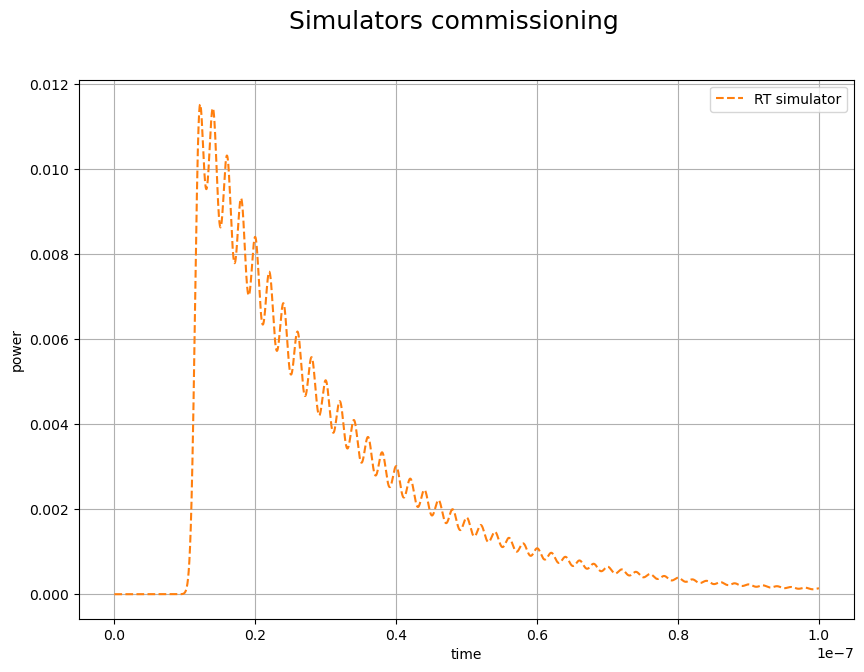

In [23]:
simulation_check_plot(ein, res, rt_sim_res, tdata, full_plot=False, batch_simulation=False)

## Plots for various detunings

![alt text](Lee_Fig.2.png)

"Fig. 2 Ring-down signals altering behaviors with the variation in excitation pulse duration and carrier frequency detuning. Excitation pulse durations for the calculations were set to be (a) 0.25t r , (b) 0.5t r , (c) t r , and (d) 2t r . For each pulse duration, several of carrier frequency detunings by (1) 0, (2) 0.25 FSR, and (3) 0.5 FSR, were considered and the corresponding results are plotted in a column.
The low finesse cavity with mirror reflectivity of 95% was considered for the calculations and the origin of the abscissa, t = 0, is set as the moment when the transmitted peak of the input pulse component undergone no round-trip is about to escape from the cavity."

In [24]:
tau_factors = [x * np.sqrt(2) for x in [0.25, .5, 1., 2.]]  # Converion for the pulse duration in field amplitude and power 
#tau_factors = [x * 1.0 for x in [0.25, .5, 1., 2.]]
detunings = [0., 0.25, 0.5]

In [ ]:
#TODO: Fix amplitude.

font_size = 14

plt.rcParams.update({'font.size': font_size})

fig, axs = plt.subplots(len(detunings), len(tau_factors), figsize=(14, 11))
#fig.suptitle(r"Ring-down signals for various pulse durations and detunings", fontsize=16)  # Commented out for publication

sumulate_batch = False

for i, detuning in enumerate(detunings):
    for j, tau_factor in enumerate(tau_factors):
        print(f"Running simulation for tau_factor={tau_factor}, detuning={detuning}")
        ein_sim, res_sim, rt_sim_res_sim, tdata_sim = simulation_check(L, detuning=detuning, tau_factor=tau_factor, batch_simulation=sumulate_batch)
        
        ax = axs[i, j]
        ax.grid(visible=True)
        ax.plot(tdata_sim, (abs(rt_sim_res_sim*t_a)**2), color='C0')
        if sumulate_batch:
            ax.plot(tdata_sim, (abs(res_sim*t_a)**2), label="Batch simulator", ls="--", color='C1')
        if j == 0:
            ax.set_ylabel("Power", fontsize=font_size)
        
        # Only add x-label to bottom row
        if i == len(tau_factors) - 1:
            ax.set_xlabel("Time [s]", fontsize=font_size)
        
        # Add title to each subplot
        if i == 0:
            ax.set_title(f"Pulse duration: {tau_factor/ np.sqrt(2)} * tau", fontsize=font_size)
        
        # Add tau_factor label on left side
        if j == 0:
            ax.text(-0.45, 0.5, f"Detuning={detuning}", transform=ax.transAxes, 
                   rotation=90, va='center', fontsize=font_size)

plt.tight_layout()
#plt.show()
plt.savefig("Fig2Lee.pdf")

Running simulation for tau_factor=0.3535533905932738, detuning=0.0
Number of points: 200000
Tau: 2.0013711752548494e-09
k: 5905249.348852994
k2j: -11810498.697705988j
desired_f_calc: 1999990000000.0002
E_in_init: 0.0
f_calc: 2000128736485.0093
N: 1
N_pre: 0.0002498299696700843
Theta: 4.999678179502496e-13
partial_Theta: False
number_of_2T_chains: 4003
f_calc_accuracy: 0.9999306314106525
RT simulation took 2.4019 seconds
